In [29]:
import sys 
import os 

sys.path.append(os.path.join('..', '..'))

In [30]:
from pathlib import Path
import pandas as pd
import numpy as np

In [31]:
data_dir = Path("../../data/base_de_dados_final/")
arquivo = data_dir / "base_sigesguarda_socioeconomica.csv"

In [32]:
df = pd.read_csv(arquivo, sep=";", encoding="latin1", dtype=str)

In [33]:
df.head()

,ATENDIMENTO_BAIRRO_NOME,FLAG_EQUIPAMENTO_URBANO,FLAG_FLAGRANTE,LOGRADOURO_NOME,NATUREZA1_DEFESA_CIVIL,NATUREZA1_DESCRICAO,NATUREZA2_DEFESA_CIVIL,NATUREZA2_DESCRICAO,NATUREZA3_DEFESA_CIVIL,NATUREZA3_DESCRICAO,...,pct_analfabetismo_15mais_estimado,domicilios_particulares_ocupados_estimado,sem_banheiro_sanitario_estimado,pct_sem_banheiro_sanitario_estimado,esgotamento_precario_estimado,pct_esgotamento_precario_estimado,sem_rede_geral_agua_estimado,pct_sem_rede_geral_agua_estimado,lixo_destino_inadequado_estimado,pct_lixo_destino_inadequado_estimado
0,cidade industrial,0,0,davi xavier da silva,0,alarmes,0,NaN,0,NaN,...,3.34,52161,47,0.09,1359,2.61,97,0.19,22,0.04
1,fazendinha,1,0,carlos klemtz,0,roubo,0,NaN,0,NaN,...,2.51,8980,3,0.04,104,1.16,6,0.07,2,0.02
2,uberaba,0,0,doutor joao de paula moura brito,0,animais,0,NaN,0,NaN,...,2.51,21881,23,0.11,1296,5.92,273,1.25,10,0.04
3,sitio cercado,0,0,edgard cavalcanti de albuquerque,0,animais,0,NaN,0,NaN,...,3.39,35174,35,0.1,331,0.94,97,0.28,3,0.01
4,tatuquara,1,0,carlos munhoz da rocha,0,alarmes,0,NaN,0,NaN,...,4.79,14960,25,0.17,1383,9.25,55,0.37,30,0.2


In [34]:
df.columns

Index(['ATENDIMENTO_BAIRRO_NOME', 'FLAG_EQUIPAMENTO_URBANO', 'FLAG_FLAGRANTE',
       'LOGRADOURO_NOME', 'NATUREZA1_DEFESA_CIVIL', 'NATUREZA1_DESCRICAO',
       'NATUREZA2_DEFESA_CIVIL', 'NATUREZA2_DESCRICAO',
       'NATUREZA3_DEFESA_CIVIL', 'NATUREZA3_DESCRICAO',
       'NATUREZA4_DEFESA_CIVIL', 'NATUREZA4_DESCRICAO',
       'NATUREZA5_DEFESA_CIVIL', 'NATUREZA5_DESCRICAO', 'OCORRENCIA_ANO',
       'OCORRENCIA_DIA_SEMANA', 'OCORRENCIA_MES', 'SECRETARIA_SIGLA',
       'SERVICO_NOME', 'NUMERO_PROTOCOLO_156', 'OCORRENCIA_DIA',
       'OCORRENCIA_HORA_HORA', 'OCORRENCIA_HORA_MINUTO', 'MADRUGADA', 'MANHA',
       'TARDE', 'NOITE', 'CRIME_VIOLENTO',
       'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL', 'ACIDENTE_TRANSITO',
       'ACIDENTE_NATURAL', 'CRIME_PATRIMONIAL', 'CRIME_ADMINISTRACAO_PUBLICA',
       'CRIME_HONRA_DISCRIMINACAO', 'CRIME_CRIANCA_ADOLESCENTE',
       'CRIME_FRAUDE_DOCUMENTAL', 'CRIME_DROGAS_SUBSTANCIAS',
       'CRIME_ORDEM_PUBLICA', 'RISCO_ESTRUTURAL',
       'EXPLOSIVOS_E_PR

### Dropando colunas desnecessárias

In [35]:
df = df.drop(columns=["LOGRADOURO_NOME", "NATUREZA1_DESCRICAO", "NATUREZA2_DESCRICAO", "NATUREZA3_DESCRICAO", "NATUREZA4_DESCRICAO", "NATUREZA5_DESCRICAO",
                      "OCORRENCIA_ANO", "NUMERO_PROTOCOLO_156", "OCORRENCIA_HORA_HORA", "OCORRENCIA_HORA_MINUTO", "tipo_estimativa", "SECRETARIA_SIGLA",
                      "resp_domicilios_particulares_estimado", "alfabetizados_15mais_estimado", "analfabetos_15mais_estimado", "pct_analfabetismo_15mais_estimado",
                      "domicilios_particulares_ocupados_estimado", "esgotamento_precario_estimado", "sem_banheiro_sanitario_estimado", "sem_rede_geral_agua_estimado",
                      "lixo_destino_inadequado_estimado", "pop_15mais_estimado"
                      ])

Seguindo o que foi discutivo em '03 - Projeto/Projeto.pdf', vamos agrupar as colunas: 

- `ACIDENTE_NATURAL`; 
- `RISCO_ESTRUTURAL`;
- `EXPLOSIVOS_E_PRODUTOS_PERIGOSOS`
- `MATERIAIS_OBJETOS`;
- `CRIME_ADMINISTRACAO_PUBLICA`;
- `PESSOAS_DESAPARECIDAS`;
- `CRIME_FRAUDE_DOCUMENTAL`;
- `CRIME_CRIANCA_ADOLESCENTE`;
- `CRIME_HONRA_DISCRIMINACAO`

em uma única coluna `OUTROS`, por serem pouco representativas. 

In [36]:
classes_outros = [
    "ACIDENTE_NATURAL",
    "RISCO_ESTRUTURAL",
    "EXPLOSIVOS_E_PRODUTOS_PERIOGOSOS",
    "MATERIAIS_OBJETOS",
    "CRIME_ADMINISTRACAO_PUBLICA",
    "PESSOAS_DESAPARECIDAS",
    "CRIME_FRAUDE_DOCUMENTAL",
    "CRIME_CRIANCA_ADOLESCENTE",
    "CRIME_HONRA_DISCRIMINACAO"
]

df["OUTROS"] = df[classes_outros].any(axis=1).astype(int)

df = df.drop(columns=classes_outros)

In [37]:
df.columns

Index(['ATENDIMENTO_BAIRRO_NOME', 'FLAG_EQUIPAMENTO_URBANO', 'FLAG_FLAGRANTE',
       'NATUREZA1_DEFESA_CIVIL', 'NATUREZA2_DEFESA_CIVIL',
       'NATUREZA3_DEFESA_CIVIL', 'NATUREZA4_DEFESA_CIVIL',
       'NATUREZA5_DEFESA_CIVIL', 'OCORRENCIA_DIA_SEMANA', 'OCORRENCIA_MES',
       'SERVICO_NOME', 'OCORRENCIA_DIA', 'MADRUGADA', 'MANHA', 'TARDE',
       'NOITE', 'CRIME_VIOLENTO', 'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL',
       'ACIDENTE_TRANSITO', 'CRIME_PATRIMONIAL', 'CRIME_DROGAS_SUBSTANCIAS',
       'CRIME_ORDEM_PUBLICA', 'ano', 'populacao_estimado',
       'rendimento_medio_responsavel_sm_estimado',
       'pct_alfabetizacao_15mais_estimado',
       'pct_sem_banheiro_sanitario_estimado',
       'pct_esgotamento_precario_estimado', 'pct_sem_rede_geral_agua_estimado',
       'pct_lixo_destino_inadequado_estimado', 'OUTROS'],
      dtype='str')

### Métodos de normalização

A normalização consiste em uma operação aplicada aos dados brutos com o objetivo de redimensioná-los ou transformá-los, de modo que todas as variáveis contribuam de forma comparável para a análise. Em aplicações de aprendizado de máquina e análise estatística, essa etapa é importante principalmente para lidar com dois problemas recorrentes: a diferença de escala entre as variáveis e a presença de valores extremos (outliers), que podem dominar os cálculos e distorcer os resultados.

No contexto deste estudo, é fundamental preservar a relação entre os valores extremos das variáveis socioeconômicas, uma vez que esses extremos representam justamente as diferenças entre os bairros com melhores e piores condições de qualidade de vida. Dessa forma, método que comprimem excessivamente os outliers poderiam reduzir informações relevantes para a construção do índice.

Por esse motivo, será utilizado o método **Min-Max Normalization (MNN)**. Esse método realiza uma transformação linear dos dados, utilzando os valores mínimo e máximo observados em cada variável para redimensioná-la para um intervalo previamente definido. Neste trabalho, os dados serão normalizados para o intervalo [0, 1], seguindo a transformação:

$$
x'_{i, n} = \left[\frac{x_{i, n} - min(x_{i})}{max(x_{i}) - min(x_{i})}\right](\text{nMax} - \text{nMin}) + \text{nMin}
$$

onde:

- $min(x_i)$ é o valor mínimo da feature $i$;
- $max(x_i)$ é o valor máximo da feature $i$;
- $\text{nMax}$ e $\text{nMin}$ correspondem, respectivamente, aos limites inferior e superior do intervalo desejado.


## Índice de qualidade de vida (IQV)

Para o desenvolvimento do índice de qualidade de vida por bairro, serão utilizadas apenas variáveis proporcionais e indicadores percentuais, uma vez que variáveis absolutas podem refletir principalmente o tmaanho populacional do bairro, dificultando comparações diretas entre diferentes regiões. 

Os indicadores selecionados foram divididos em dois grupos, de acordo com a interpretação de seus valores em relação à qualidade de vida.

### 1. Indicadores positivos

Neste grupo, valores mais elevados indicam melhores condições socioeconômicas e, consequentemente, maior qualidade de vida:

- `rendimento_medio_responsavel_sm_estimado`;
- `pct_alfabetizacao_15mais_estimado`.

Como a variável de rendimento apresenta distribuição assimétrica à direita (*right-skewed*), será aplicada inicialmente uma transformação logarítmica, com o objetivo de reduzir a influência de valores extremos e melhorar a distribuição dos dados antes da normalização.

### 1. Indicadores negativos

Neste grupo, valores mais elevados representam condições mais precárias de infraestrutura urbana e sanemaneto básico, indicando pior qualidade de vida:

- `pct_sem_banheiro_sanitario_estimado`;
- `pct_esgotamento_precario_estimado`;
- `pct_sem_rede_geral_agua_estimado`;
- `pct_lixo_destinado_inadequado_estimado`.


Após a selação das variáveis, será aplicada a normalização Min-Max para transformar todos os indicadores em uma mesma escala no intervalo [0, 1].

Para os indicadores positivos, será utilizada a transformação:

$$
x_{norm} = \frac{x - min(x)}{max(x) - min(x)}
$$

de modo que:

- o menor valor observado seja transformado em 0;
- o maior valor observado seja transformado em 1.

Por fim, o IQV de cada bairro b será calculado a partir da média aritmética dos indicadores normalizados:

$$
\text{IQV}_{b} = \frac{100}{k}\sum_{j = 1}^{k}x_{k, j}^{\text{norm}}
$$

onde:

- $k$ representa o número total de indicadores utilizados;
- $x_{b, j}^{\text{norm}}$ corresponde ao valor normalizado do indicador $j$ para o bairro $b$.

A multiplicações por 100 tem como objetivo facilitar a interpretação do índice final, que passará a variar entre 0 e 100, sendo que valores mais elevados indicam melhores condições relativas de qualidade de vida.

Para os indicadores negativos, será utilizada a transformação inversa:

$$
x_{norm} = \frac{max(x) - x}{max(x) - min(x)}
$$

Nesse caso:

- bairros em piores condições recebem valores próximos de 0;
- bairros em melhores condições recebem valores próximos de 1.

Assim, todos os indcadores passam a possuir a mesma interpretação: valores mais próximos de 1 representam melhores condições d equalidade de vida.

In [38]:
def minmax(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    
    df = df.copy()

    for column in columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

        max = df[column].max()
        min = df[column].min()

        diff = max - min

        if diff == 0:
            df[column + "_norm"] = 0
        else:
            df[column + "_norm"] = (df[column] - min) / diff

    return df

In [39]:
def maxmin(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:

    df = df.copy()

    for column in columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

        max = df[column].max()
        min = df[column].min()

        diff = max - min 

        if diff == 0:
            df[column + "_norm"] = 0
        else:
            df[column + "_norm"] = (max - df[column]) / diff
    
    return df

Agora, visualizaremos a distribuição do rendimento médio do responsável em salários mínimos:

<Axes: >

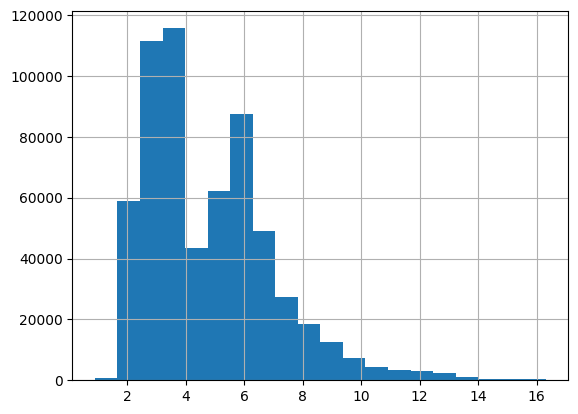

In [40]:
df["rendimento_medio_responsavel_sm_estimado"] = pd.to_numeric(df["rendimento_medio_responsavel_sm_estimado"], errors="coerce")

df["rendimento_medio_responsavel_sm_estimado"].hist(bins=20)

Aplicando o logaritmo na base 10, a distribuição passa a ser:

<Axes: >

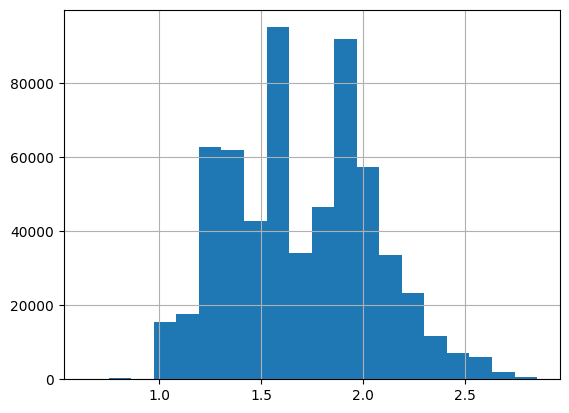

In [41]:
df["log_rendimento"] = np.log1p(df["rendimento_medio_responsavel_sm_estimado"])

df["log_rendimento"].hist(bins=20)

Faremos o mesmo para a populacao:

<Axes: >

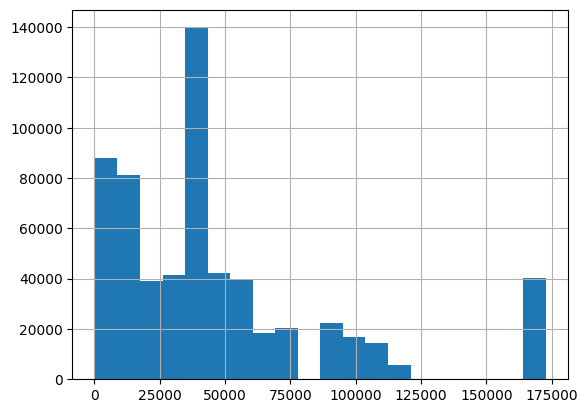

In [42]:
df["populacao_estimado"] = pd.to_numeric(df["populacao_estimado"], errors="coerce")

df["populacao_estimado"].hist(bins=20)

<Axes: >

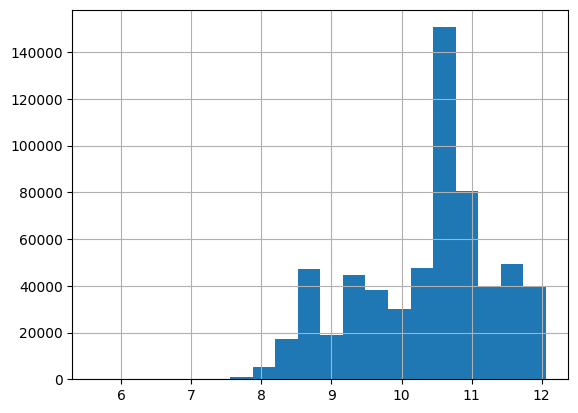

In [43]:
df["log_pop"] = np.log1p(df["populacao_estimado"])

df["log_pop"].hist(bins=20)

In [44]:
df = df.drop(columns=["rendimento_medio_responsavel_sm_estimado"])

In [45]:
variaveis_positivas = [
    "log_rendimento",
    "pct_alfabetizacao_15mais_estimado"
]

variaveis_negativas = [
    "pct_sem_banheiro_sanitario_estimado",
    "pct_esgotamento_precario_estimado",
    "pct_sem_rede_geral_agua_estimado",
    "pct_lixo_destino_inadequado_estimado"
]

In [46]:
df = minmax(df, variaveis_positivas)
df = maxmin(df, variaveis_negativas)

In [47]:
cols_originais = variaveis_positivas + variaveis_negativas
cols_norm = [c + "_norm" for c in cols_originais]

Calculando o IQV por bairro:

In [48]:
df["IQV"] = df[cols_norm].mean(axis=1) * 100

In [49]:
df.groupby("ATENDIMENTO_BAIRRO_NOME")["IQV"].mean()

ATENDIMENTO_BAIRRO_NOME
abranches              83.352980
agua verde             95.314220
ahu                    95.685692
alto boqueirao         81.344939
alto da gloria         95.358370
alto da xv             94.601332
atuba                  84.859751
augusta                75.945184
bacacheri              92.486213
bairro alto            85.978166
barreirinha            86.609881
batel                  97.957096
bigorrilho             85.035532
boa vista              90.080573
bom retiro             92.420605
boqueirao              85.944759
butiatuvinha           82.555784
cabral                 95.728335
cachoeira              76.534569
cajuru                 78.359253
campina do siqueira    89.340013
campo comprido         87.068379
campo do santana       76.032621
capao da imbuia        87.488434
capao raso             87.001834
cascatinha             91.737123
caximba                27.976107
centro                 91.441732
centro civico          93.991914
cidade industrial  

In [50]:
iqv_bairros = (
    df.groupby("ATENDIMENTO_BAIRRO_NOME")["IQV"]
    .mean()
    .reset_index()
)

iqv_bairros.sort_values("IQV", ascending=False).head(10)

,ATENDIMENTO_BAIRRO_NOME,IQV
11,batel,97.957096
40,jardim social,95.918059
17,cabral,95.728335
2,ahu,95.685692
37,hugo lange,95.661585
45,mossungue,95.610287
4,alto da gloria,95.358370
1,agua verde,95.314220
5,alto da xv,94.601332
41,juveve,94.435955


In [51]:
iqv_bairros.sort_values("IQV", ascending=True).head(10)

,ATENDIMENTO_BAIRRO_NOME,IQV
26,caximba,27.976107
54,riviera,64.389522
33,ganchinho,71.918446
52,prado velho,72.779695
63,sao miguel,72.798453
68,tatuquara,75.842038
7,augusta,75.945184
22,campo do santana,76.032621
18,cachoeira,76.534569
71,umbara,77.114779


In [52]:
iqv_bairros.sort_values("IQV").head(10)

,ATENDIMENTO_BAIRRO_NOME,IQV
26,caximba,27.976107
54,riviera,64.389522
33,ganchinho,71.918446
52,prado velho,72.779695
63,sao miguel,72.798453
68,tatuquara,75.842038
7,augusta,75.945184
22,campo do santana,76.032621
18,cachoeira,76.534569
71,umbara,77.114779


In [53]:
ranking = (
    iqv_bairros
    .sort_values("IQV", ascending=False)
    .reset_index(drop=True)
)

ranking["ranking"] = ranking.index + 1

pd.set_option("display.max_rows", None)

ranking

,ATENDIMENTO_BAIRRO_NOME,IQV,ranking
0,batel,97.957096,1
1,jardim social,95.918059,2
2,cabral,95.728335,3
3,ahu,95.685692,4
4,hugo lange,95.661585,5
5,mossungue,95.610287,6
6,alto da gloria,95.358370,7
7,agua verde,95.314220,8
8,alto da xv,94.601332,9
9,juveve,94.435955,10


In [54]:
df_final = df.drop(columns=cols_originais, errors="ignore")

In [55]:
arquivo_feature_engineering = data_dir / "base_feature_engineering.csv"

In [56]:
df_final.to_csv(arquivo_feature_engineering, index=False)